# Fine-Tuning a Language Model with LoRA and DPO

> ↩ **Previous in the series:** [Building a BPE Tokenizer from Scratch](tokenizer.ipynb)


The [transformer notebook](../transformer/notebook.ipynb) built a GPT from scratch and trained it on Shakespeare. That gave us a **pretrained** model: one that predicts the next token well, having seen a mountain of text. But a raw pretrained model just *continues* text — ask it a question and it might reply with more questions, because that's what web text looks like. This notebook is about the second half of the story: **taking a model that already knows language and shaping it to be useful** — to follow instructions and to answer *well*.

We do it on a real 1.1-billion-parameter model (TinyLlama), on a laptop, using three techniques that stack:

| Step | What we do | The question it answers |
|------|-----------|-------------------------|
| 0 | Load TinyLlama | What can a pretrained model do out of the box? |
| 1 | LoRA | How do we afford to train a 1.1B-parameter model on a laptop? |
| 2 | SFT (supervised fine-tuning) | How do we teach it to *answer* a question? |
| 3 | DPO (direct preference optimization) | How do we teach it to answer *well*? |

**The through-line.** Everything hangs off the pipeline **pretrain → SFT → DPO**, the same recipe behind ChatGPT and friends:
- *Pretraining* (done for us — TinyLlama) teaches raw language from trillions of tokens.
- *SFT* shows the model examples of good question→answer pairs and has it imitate them. It's the exact next-token training from the transformer notebook, just on instruction data.
- *DPO* goes further: it shows the model **pairs** of answers labeled better/worse and pushes it toward the better one. This is where "helpful, not just fluent" comes from.
- *LoRA* is the enabling trick underneath SFT and DPO: instead of updating all 1.1B weights, we train a tiny add-on (a few million parameters), which is what makes this run on a MacBook at all.

Our concrete running example: we'll take TinyLlama, which gives vague medical answers, and fine-tune it on medical flashcards, comparing its answers to the *same three medical questions* before SFT, after SFT, and after DPO.

> **A note for this audience.** This assumes you know math and code but not statistics or ML. The ideas that rest on probability — the softmax/log-probabilities behind "how likely is this answer," the sigmoid function and KL divergence inside DPO — are each built up from scratch in plain terms before they're used. LoRA, by contrast, rests on plain linear algebra (matrix rank), which we lean on directly. Watch for the `>` callout boxes.

**Requirements:** MacBook with 8GB+ RAM. All training runs on CPU or MPS (Apple Silicon GPU). No CUDA/NVIDIA needed. The base model is a ~4.4 GB download the first time.

## Setup

We need several libraries:
- `transformers` — load and run language models from Hugging Face
- `peft` — implements LoRA (Parameter-Efficient Fine-Tuning)
- `trl` — training helpers for SFT and DPO
- `datasets` — load training datasets from Hugging Face

In [1]:
import os
# Allow MPS to fall back to CPU for unsupported operations
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'

import torch
import matplotlib.pyplot as plt
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, TaskType
from datasets import load_dataset
from trl import SFTConfig, SFTTrainer, DPOConfig, DPOTrainer

# Use MPS (Apple Silicon GPU) if available, otherwise CPU
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

Using device: mps


## Step 0: Load the Base Model

**What we're doing:** Loading TinyLlama (1.1B parameters) — a small pretrained language model that can run on a MacBook.

**How it works:** TinyLlama was pretrained on 3 trillion tokens of text from the internet. It learned to predict the next token given previous tokens — the same objective as our GPT from the transformer notebook, but trained on vastly more data with a much larger model. It already knows English grammar, facts, and patterns.

> **An honest caveat about our "base" model.** The checkpoint we load is TinyLlama-1.1B-**Chat** — its authors already ran it through a general-purpose SFT + DPO pass, so it *can* follow instructions. Why not start from the truly raw pretrained TinyLlama? A raw model just continues text — ask it a question and it may reply with more questions — which makes every before/after comparison noisy. The chat variant gives a stable baseline that answers questions, but only *generically*: it has no medical specialization, and that gap is exactly what our fine-tuning closes. So in this notebook "base model" means "before **our** fine-tuning," and the pipeline we run is the same recipe its creators used — re-run on our own data, one level up.

**Why TinyLlama?** At 1.1B parameters, it's small enough to finetune on a laptop (~2-4GB memory with LoRA) but large enough to produce coherent text. Larger models (7B+) would need a GPU with more VRAM.

**What's a tokenizer?** The tokenizer converts text to token IDs and back. Unlike our character-level tokenizer from the transformer notebook, this uses BPE (Byte-Pair Encoding) with a ~32k vocabulary — common words like `"the"` are single tokens, while rare words are split into subwords.

In [2]:
model_name = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'

# Load the tokenizer — converts text ↔ token IDs
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Load the model in fp32 (full precision) — safest for MPS/CPU training
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float32,  # fp16/bf16 can cause NaN on MPS
)

# Align pad token across tokenizer, model config, and generation config
# so no component sees a mismatch
tokenizer.pad_token = tokenizer.eos_token
base_model.config.pad_token_id = tokenizer.pad_token_id
base_model.generation_config.pad_token_id = tokenizer.pad_token_id
# Clear default max_length — we always set max_new_tokens explicitly
base_model.generation_config.max_length = None

total_params = sum(p.numel() for p in base_model.parameters())
print(f'Model: {model_name}')
print(f'Parameters: {total_params:,}')
print(f'Size in memory: ~{total_params * 4 / 1e9:.1f} GB (fp32)')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model: TinyLlama/TinyLlama-1.1B-Chat-v1.0
Parameters: 1,100,048,384
Size in memory: ~4.4 GB (fp32)


### Generate with the base model

Let's ask the base model some medical questions *before* any finetuning. TinyLlama-Chat can follow instructions but has no specialized medical training — it will give generic, often vague answers. After SFT on medical flashcards, the answers should become noticeably more specific and clinical.

The `generate` function below produces text exactly the way the transformer notebook did — predict next-token logits, softmax to probabilities, sample one token, append, repeat — but with three standard knobs that shape the sampling. Introducing them once here, since every generation in this notebook uses them:

> **Sampling knobs.**
> - **`temperature=0.7`** — divides the logits before softmax. Below 1 sharpens the distribution (the model plays it safe, picking high-probability tokens more often); above 1 flattens it (more random, more creative). At 0 it becomes pure argmax. This is the same "temperature" slider you see on LLM APIs.
> - **`top_p=0.9`** (nucleus sampling) — before sampling, keep only the most probable tokens whose probabilities add up to 0.9, and renormalize. It clips off the long tail of unlikely garbage tokens without hard-capping the count.
> - **`repetition_penalty=1.2`** — down-weights tokens already generated, to stop the model looping ("the the the"). A small model with no such penalty degenerates into repetition quickly.
>
> `do_sample=True` turns on random sampling (vs. deterministic argmax). Because we sample, answers vary run to run.

In [3]:
def generate(model, prompt, max_new_tokens=100):
    """Generate text from a prompt using the model."""
    was_training = model.training
    model.eval()  # disable dropout and gradient checkpointing for generation
    
    messages = [{'role': 'user', 'content': prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors='pt').to(model.device)
    
    with torch.no_grad():
        outputs = model.generate(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            repetition_penalty=1.2,  # penalize repeating the same token
        )
    response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    
    if was_training:
        model.train()  # restore training mode if it was on before
    return response.strip()

# Medical questions — compare these answers before and after LoRA finetuning
medical_prompts = [
    'What are the common symptoms of pneumonia?',
    'What is the difference between type 1 and type 2 diabetes?',
    'What is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels?'
]

print('--- Base model (before finetuning) ---')
for p in medical_prompts:
    print(f'\nQ: {p}')
    print(f'A: {generate(base_model, p)}')

--- Base model (before finetuning) ---

Q: What are the common symptoms of pneumonia?


A: Yes, here are some common symptoms of pneumonia:
1. Coughing up phlegm or mucus-filled sputum (yellow or brown in color)
2. Fever that may be high or low (high fever can cause a rash or shaking chills)
3. Chest pain or tightness
4. Slow breathing and shortness of breath (wheezing sounds when you breathe out)

Q: What is the difference between type 1 and type 2 diabetes?


A: Type 1 diabetes (T1D) and Type 2 diabetes are two different types of diabetes that occur in different ways. Here's a brief explanation:

1. Type 1 Diabetes: This form of diabetes occurs when the body's immune system destroys insulin-producing cells called beta cells, which regulate blood sugar levels. Symptoms include high blood sugar levels, fatigue, weight loss

Q: What is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels?


A: The following table shows the possible relationships between various mineral levels in bones:

Mineral Level | Relationship with PTH (Parathyroid Hormone) Levels
-----------------|---------------
Ca2+             | Decreased PTH levels lead to increased calcium levels in bone tissue.
Alkaline Phosphatase  | Increases PTH levels due to reduced production of alkaline phosphatase by o


## Step 1: Understanding LoRA

**What changes:** instead of updating all 1.1 billion parameters, we **freeze** the whole model and bolt on tiny trainable matrices in a few layers. Only those add-ons (~0.2% of the parameters) get gradients. LoRA = **Lo**w-**R**ank **A**daptation.

### The problem LoRA solves

Fine-tuning means nudging weights to change behavior. But a full fine-tune of TinyLlama means computing and storing gradients + optimizer state for 1.1B parameters — several times the 4.4 GB model itself, more than a laptop has. And every saved fine-tune is another full 4.4 GB copy. LoRA sidesteps both.

### The bet: the *change* is low-rank

A weight matrix `W` in an attention layer is `2048 × 2048` ≈ 4.2M numbers. Fine-tuning replaces `W` with `W + ΔW`, where `ΔW` is the *change* learned during training. LoRA's bet is that **`ΔW` has low rank** — so it can be stored in a far cheaper factored form.

> **Rank, concretely.** The **rank** of a matrix is the number of linearly independent rows (equivalently, columns) — the true dimensionality of the transformation it performs. Watch a rank-1 matrix compress. This 3×3 matrix looks like 9 independent numbers:
>
> ```
>     [ 2  4  6 ]       [1]
>     [ 4  8 12 ]   =   [2]  @  [ 2 4 6 ]
>     [ 6 12 18 ]       [3]
> ```
>
> But every row is a multiple of `[2 4 6]`, so the whole thing is one column vector times one row vector — 6 numbers, not 9. At 3×3 the saving is trivial; at 2048×2048 it's enormous. Rank `r` generalizes this: a rank-`r` matrix, however large, factors exactly into a tall × wide product `B @ A` where `B` is `2048 × r` and `A` is `r × 2048` — all its information lives in `r` directions. The claim backed by research: the *update* `ΔW` from fine-tuning is approximately low-rank — adaptation only really moves the model along a handful of directions — even though `W` itself is full-rank.

### The mechanics

LoRA never forms the big `ΔW`. It:

1. **Freezes** `W` (no gradients).
2. Adds two small matrices: `A` of shape `(r, 2048)` and `B` of shape `(2048, r)`, with `r` tiny (here 8). `B` starts at zero, so `B @ A = 0` and the adapter initially adds nothing — training starts exactly at the pretrained model.
3. Computes the layer as `W @ x + (B @ A) @ x`. The learned update is `ΔW = B @ A`: a full `2048 × 2048` matrix expressed with only `2 × 2048 × 8 = 32,768` numbers instead of 4.2M — a **~128× reduction** per matrix.

### The two knobs

- **`r` — capacity.** The maximum rank the adapter can express. Since the needed update is nearly low-rank, a small `r` captures most of it; bigger `r` adds capacity, memory, and training cost. 8–16 is the usual range.
- **`lora_alpha` — scale.** A fixed multiplier on the adapter's contribution: the effective update is `(lora_alpha / r) · B @ A`; with `alpha=16, r=8` that's `2×`. It decouples "how big is the update" from "how expressive is it (`r`)", so you can retune `r` without re-tuning the learning rate.

### Which layers get LoRA

The attention projections `q_proj, k_proj, v_proj, o_proj` — the very Q/K/V/output matrices from the transformer notebook, where the model decides what to attend to. Adapting these moves behavior the most per parameter.

### Why this matters in the real world

Because the adapter is a few MB, you can fine-tune a 70B model on a single GPU (train the adapter, keep the giant base frozen), ship a 10 MB file per task instead of a multi-GB model, and hot-swap adapters on one shared base — which is exactly what we do in the DPO generation step at the end.


In [4]:
# Configure LoRA: which layers to adapt, and how much capacity to give them
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,       # we're doing next-token prediction
    r=8,                                 # rank of the A and B matrices — lower = fewer params
    lora_alpha=16,                       # scaling factor — actual scale is alpha/r = 2.0
    lora_dropout=0.05,                   # dropout on LoRA layers to prevent overfitting
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj'],  # attention layers only
)

# Wrap the base model with LoRA — freezes base weights, adds trainable A/B matrices
model = get_peft_model(base_model, lora_config)

# Show what happened
model.print_trainable_parameters()

trainable params: 2,252,800 || all params: 1,102,301,184 || trainable%: 0.2044


Notice the output: out of ~1.1B total parameters, only a few million are trainable. The rest are frozen — they contribute to the forward pass but don't receive gradient updates during training.

Let's inspect what LoRA actually added to the model:

In [5]:
# Look at one attention layer to see the LoRA matrices
layer = model.base_model.model.model.layers[0].self_attn

print('Q projection structure (original weight + LoRA A and B):')
print(layer.q_proj)
print()

# The LoRA matrices are tiny compared to the original weight
W = layer.q_proj.base_layer.weight
A = layer.q_proj.lora_A['default'].weight
B = layer.q_proj.lora_B['default'].weight
print(f'Original W shape: {W.shape}  ({W.numel():,} params) — FROZEN')
print(f'LoRA A shape:     {A.shape}  ({A.numel():,} params) — trainable')
print(f'LoRA B shape:     {B.shape}  ({B.numel():,} params) — trainable')
print(f'LoRA adds {A.numel() + B.numel():,} params vs {W.numel():,} original — {(A.numel() + B.numel()) / W.numel() * 100:.1f}% of the layer')

Q projection structure (original weight + LoRA A and B):
lora.Linear(
  (base_layer): Linear(in_features=2048, out_features=2048, bias=False)
  (lora_dropout): ModuleDict(
    (default): Dropout(p=0.05, inplace=False)
  )
  (lora_A): ModuleDict(
    (default): Linear(in_features=2048, out_features=8, bias=False)
  )
  (lora_B): ModuleDict(
    (default): Linear(in_features=8, out_features=2048, bias=False)
  )
  (lora_embedding_A): ParameterDict()
  (lora_embedding_B): ParameterDict()
  (lora_magnitude_vector): ModuleDict()
)

Original W shape: torch.Size([2048, 2048])  (4,194,304 params) — FROZEN
LoRA A shape:     torch.Size([8, 2048])  (16,384 params) — trainable
LoRA B shape:     torch.Size([2048, 8])  (16,384 params) — trainable
LoRA adds 32,768 params vs 4,194,304 original — 0.8% of the layer


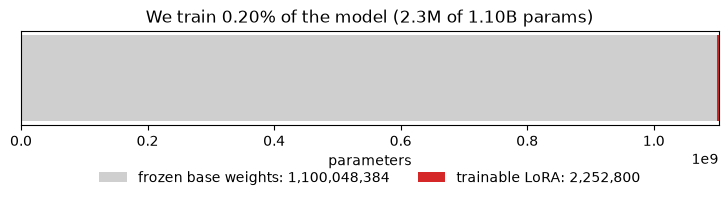

Full fine-tune would train 1,102,301,184 params.
LoRA trains 2,252,800 — a 489x reduction in what needs gradients + optimizer state.


In [6]:
# Visualize how little we actually train. The red sliver is the entire trainable footprint.
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
frozen = total - trainable
pct = 100 * trainable / total

fig, ax = plt.subplots(figsize=(9, 2.2))
ax.barh(0, frozen, color='#cfcfcf', label=f'frozen base weights: {frozen:,}')
ax.barh(0, trainable, left=frozen, color='#d62728', label=f'trainable LoRA: {trainable:,}')
ax.set_xlim(0, total)
ax.set_yticks([])
ax.set_xlabel('parameters')
ax.set_title(f'We train {pct:.2f}% of the model ({trainable/1e6:.1f}M of {total/1e9:.2f}B params)')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.35), ncol=2, frameon=False)
fig.subplots_adjust(bottom=0.45)   # room for the legend below the axis
plt.show()

print(f'Full fine-tune would train {total:,} params.')
print(f'LoRA trains {trainable:,} — a {total/trainable:.0f}x reduction in what needs gradients + optimizer state.')

## Step 2: Supervised Fine-Tuning (SFT)

**What changes:** we train the LoRA adapter on medical Q&A pairs so the model learns to answer medical questions. Good test for LoRA: the base model has general knowledge but no medical specialization, so any medical competence in the output has to come from the tiny adapter.

**How it works — it's the transformer notebook's training, on new data.** SFT is *exactly* next-token prediction with cross-entropy loss. We feed the model the formatted `question + answer` as one token sequence, and at every position it predicts the next token; the loss is the same `-log(probability it gave the correct next token)` from the transformer notebook, averaged over the sequence. (With our setup that average includes the *question's* tokens too, so the model gets a little training signal on question phrasing as well. `trl` can mask the loss to the answer alone (`assistant_only_loss=True`); for a short demo the default is fine.) The only twist is that gradients update just the LoRA `A` and `B` matrices — `W` is frozen.

> **The probability a model assigns to a whole response.** This idea underpins both the SFT loss and (crucially) DPO, so pin it down now. The model scores one token at a time. The probability it assigns to an entire response is the product of its per-token probabilities: `P(response) = p(t₁) · p(t₂) · … · p(t_n)`. Multiplying hundreds of numbers below 1 underflows to zero, so we always work in **log-probabilities** and add instead: `log P(response) = log p(t₁) + … + log p(t_n)` (logs turn products into sums, and `log` is monotonic so "more likely" still means "larger"). Concretely, a 3-token response with per-token probabilities `0.8, 0.5, 0.9`: `P = 0.36`, and `log P = (−0.22) + (−0.69) + (−0.11) = −1.02`. Log-probs are always ≤ 0, and more negative = less likely. "The model prefers response X" means precisely "X has the higher `log P`." SFT pushes up `log P(good answer)`; DPO will push `log P(chosen)` up *relative to* `log P(rejected)`.

**What backprop looks like with LoRA:** the forward pass is `W @ x + (B @ A) @ x`; on the backward pass gradients flow through `B @ A` and update only `A` and `B` (the frozen `W` has `requires_grad = False`). That's why LoRA is light — gradients and optimizer state exist for ~0.2% of the parameters.

**The training data:** medical flashcards — short `question → answer` pairs. We wrap each as a two-message chat (`user` question, `assistant` answer) so it matches the chat template TinyLlama-Chat was trained on.

**Why `SFTTrainer`:** we *could* hand-write the loop (we did, in the transformer notebook), but `SFTTrainer` from `trl` handles chat-template formatting, tokenization, padding, and batching — the standard instruction-tuning tool.

> **Training knobs you'll see in `SFTConfig`.**
> - **epoch** = one full pass over the dataset. We do 1.
> - **`per_device_train_batch_size=1` + `gradient_accumulation_steps=8`** = accumulate gradients over 8 examples before each weight update, giving an effective batch of 8 while only ever holding 1 example in memory (the memory/steadiness trade-off from the transformer notebook's mini-batch discussion).
> - **`learning_rate=2e-4`** — larger than pretraining; LoRA tolerates it because so few parameters move.
> - **`gradient_checkpointing=True`** — recompute activations during backprop instead of storing them: less memory, more compute.

In [7]:
# Load medical flashcards — short Q&A pairs about medical topics
dataset = load_dataset('medalpaca/medical_meadow_medical_flashcards', split='train')

# Use a small subset — enough to see the effect, fast enough for a laptop
dataset = dataset.select(range(500))

# Format as chat messages so SFTTrainer can apply the model's chat template
def format_medical(example):
    return {
        'messages': [
            {'role': 'user', 'content': example['input']},
            {'role': 'assistant', 'content': example['output']},
        ]
    }

dataset = dataset.map(format_medical, remove_columns=dataset.column_names)

print(f'Training examples: {len(dataset)}')
print(f'\nExample:')
for msg in dataset[0]['messages']:
    text = msg['content'][:120] + '...' if len(msg['content']) > 120 else msg['content']
    print(f"  [{msg['role']}]: {text}")

Training examples: 500

Example:
  [user]: What is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels?
  [assistant]: Very low Mg2+ levels correspond to low PTH levels which in turn results in low Ca2+ levels.


In [8]:
# Configure training — tuned for 16GB MacBook
sft_config = SFTConfig(
    output_dir='./sft-output',
    num_train_epochs=1,              # one pass through the data
    per_device_train_batch_size=1,   # minimal batch size to save memory
    gradient_accumulation_steps=8,   # simulate batch_size=8 over multiple steps
    learning_rate=2e-4,              # higher than pretraining — LoRA can handle it
    max_length=256,                  # shorter sequences use less memory
    logging_steps=10,                # log loss every 10 steps so we can track progress
    save_strategy='no',              # don't save checkpoints (saves disk space)
    fp16=False, bf16=False,          # fp32 only — fp16/bf16 cause NaN on MPS
    gradient_checkpointing=True,     # trade compute for memory — recompute activations instead of storing them
    dataloader_pin_memory=False,     # pin_memory not supported on MPS
    report_to='none',               # disable wandb/mlflow logging
    disable_tqdm=False,              # show progress bar
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=dataset,
    processing_class=tokenizer,
)

print(f'Training {trainer.args.num_train_epochs} epoch(s), '
      f'{len(trainer.get_train_dataloader())} steps, '
      f'logging every {sft_config.logging_steps} steps')
trainer.train()
print('Done!')

Training 1 epoch(s), 500 steps, logging every 10 steps


Step,Training Loss
10,1.362073
20,1.047021
30,1.039071
40,0.992330
50,1.005814
60,0.980844


Done!


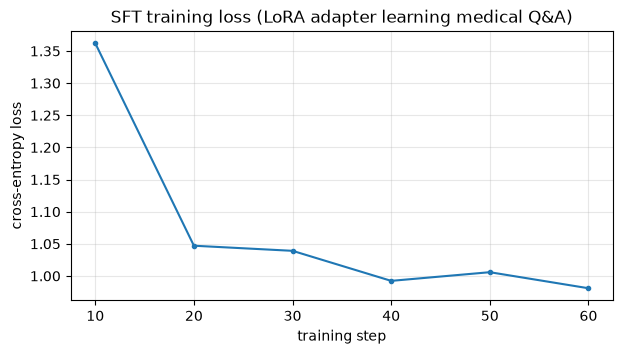

loss: 1.362 (start) -> 0.981 (end)


In [9]:
# The trainer logged the loss every 10 steps into trainer.state.log_history.
# Plot it: this is the same cross-entropy loss falling as the LoRA adapter learns.
sft_logs = [h for h in trainer.state.log_history if 'loss' in h]

if not sft_logs:
    print('No loss logged; keys present:', sorted({k for h in trainer.state.log_history for k in h}))
else:
    steps = [h['step'] for h in sft_logs]
    losses = [h['loss'] for h in sft_logs]
    plt.figure(figsize=(7, 3.5))
    plt.plot(steps, losses, marker='o', ms=3, color='#1f77b4')
    plt.xlabel('training step'); plt.ylabel('cross-entropy loss')
    plt.title('SFT training loss (LoRA adapter learning medical Q&A)')
    plt.grid(alpha=0.3)
    plt.show()
    print(f'loss: {losses[0]:.3f} (start) -> {losses[-1]:.3f} (end)')

### Generate after SFT

The LoRA adapter has been trained on 500 medical flashcards. The base weights are unchanged — only the small A and B matrices were updated. Let's ask the same medical questions and compare.

We also save the adapter so the DPO step can continue from it.

In [10]:
from IPython.display import display, Markdown

# Save the SFT adapter — DPO will load this to continue from where SFT left off
model.save_pretrained('./sft-adapter')
print(f'SFT adapter saved to ./sft-adapter/')

# Generate answers from both models and display side by side
rows = ['| Question | Base Model | After SFT |\n|----------|------------|-----------|']
for p in medical_prompts:
    base_answer = generate(base_model, p).replace('\n', ' ').replace('|', '\\|')
    sft_answer = generate(model, p).replace('\n', ' ').replace('|', '\\|')
    rows.append(f'| {p} | {base_answer[:200]} | {sft_answer[:200]} |')

display(Markdown('\n'.join(rows)))

SFT adapter saved to ./sft-adapter/


| Question | Base Model | After SFT |
|----------|------------|-----------|
| What are the common symptoms of pneumonia? | Pneumonia is a lung infection caused by bacteria or fungi, and it can be diagnosed based on several specific symptoms. These include fever, cough, chest pain, shortness of breath, wheezing, and decrea | Pneumonia is a type of bacterial infection that can affect the lungs and cause inflammation. Common symptoms of pneumonia include fever, chest pain or pressure, coughing up blood, shortness of breath, |
| What is the difference between type 1 and type 2 diabetes? | Type 1 diabetes is a autoimmune disease that causes insulin deficiency, whereas type 2 diabetes is due to increased production of antibodies against insulin. Both types require regular monitoring for  | Type 1 diabetes is a condition in which the body does not produce insulin, while type 2 diabetes is caused by the presence of abnormal cells or tissues that do not produce enough insulin. This means t |
| What is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels? | Very low Mg2+ levels can lead to high PTH levels. This is because excessive PTH production in response to a low level of Mg2+ causes hypercalcemia by stimulating calcium uptake into cells. High PTH le | Very low Mg2+ levels can lead to a decrease in calcium (Ca) levels. This can be due to an increase in parathyroid hormone (PTH), which increases the level of calcium ions in the body through the stimu |

## Step 3: DPO (Direct Preference Optimization)

**What changes:** SFT taught the model to *produce* answers by imitating good ones. DPO teaches it to *prefer* the better of two answers. The data is now **triplets** `(prompt, chosen, rejected)`, and we push the model to score `chosen` above `rejected`.

**Why SFT isn't enough:** SFT imitates whatever answers are in its data, treating them all as equally good. But given "Explain gravity," one answer is crisp and correct, another vague and rambling — SFT can't tell them apart. Human preferences are easier to *compare* than to *write*: it's hard to author the perfect answer, easy to say "this one's better." DPO learns from exactly those comparisons. This is the alignment step that makes assistants like ChatGPT feel helpful rather than merely fluent.

**The setup — policy and reference.** Two models are involved:
- the **policy** `πθ` — the model we're training (SFT adapter, now being refined by DPO);
- the **reference** `π_ref` — a frozen anchor. With LoRA it's free: it's just the policy with the adapter switched off, i.e. the base model. It stops the policy from wandering off and forgetting everything it knows.

Recall from Step 2 that a model assigns each response a **log-probability** `log P(response)`. DPO works entirely with these.

### The two statistics ideas DPO needs

> **Sigmoid (the logistic function).** `σ(z) = 1 / (1 + e^(−z))`. It squashes any real number into `(0, 1)`: `σ(0) = 0.5`, large positive `z → 1`, large negative `z → 0`, a smooth S-curve. Use it whenever you want to turn an unbounded score into a probability of a yes/no outcome — here, "is `chosen` really better than `rejected`?" (The plot below makes its shape concrete.)

> **KL divergence.** A single number ≥ 0 measuring how far one probability distribution is from another; it's 0 exactly when they're identical and grows as they diverge. In DPO it measures how far the policy has drifted from the reference. We don't compute it directly — the `beta` knob *implicitly* controls it: bigger `beta` keeps the policy closer to the reference (small KL), smaller `beta` lets it move more.

### The DPO loss, decoded

For each triplet, define an **implicit reward** for a response `y`: how much more the policy likes it than the reference does,

```
r(y) = log πθ(y | prompt) − log π_ref(y | prompt)
```

Then the loss for one `(prompt, chosen, rejected)` triplet is

```
loss = − log σ( β · [ r(chosen) − r(rejected) ] )
```

Read it inside-out:
- `r(chosen) − r(rejected)` is the **preference margin**: how much more the policy prefers the good answer over the bad one, *beyond* whatever the reference already preferred. Positive = the policy ranks them correctly.
- `β · margin` scales it (same `β` that controls the drift), and `σ(·)` turns it into a probability that the model ranks the pair correctly.
- `− log σ(·)` is the **exact surprise-meter loss from the transformer notebook** (`−log p`): near 0 when the margin is large and positive (model confidently prefers `chosen`), large when the margin is negative (model wrongly prefers `rejected`). Minimizing it drives every margin positive.

**One triplet, with numbers.** Say the policy assigns the chosen answer `log πθ = −5.0` where the reference assigns `−6.0`: `r(chosen) = −5.0 − (−6.0) = +1.0` — training has made the good answer more likely than it used to be. For the rejected answer, policy `−4.0`, reference `−3.5`: `r(rejected) = −0.5`. The margin is `1.0 − (−0.5) = 1.5`; with `β = 0.1`, `z = 0.15`, `σ(0.15) ≈ 0.54`, so `loss = −log 0.54 ≈ 0.62`. The pair is ranked correctly, but barely — the loss sits well above 0, so gradients keep pushing to widen the margin.

That's the whole method: it's **logistic regression on preference pairs**. Gradient descent raises `log πθ(chosen)` and lowers `log πθ(rejected)`, with the reference term keeping the model honest. No reward model, no reinforcement learning.

**Why DPO instead of RLHF:** classic RLHF trains a separate reward model, then uses PPO (a reinforcement-learning algorithm) to optimize against it — two models and an unstable RL loop. DPO collapses that into the single classification loss above: same goal, one training loop, far less to go wrong.

**Memory trick with LoRA:** normally the reference would be a second full copy of the model (~4.4 GB more). With LoRA, `DPOTrainer` gets the reference for free by disabling the adapter — the frozen base weights *are* the reference. We pass `ref_model=None` to enable this.

**Note:** we free the SFT model and its trainer from memory before loading the DPO model, to stay within laptop RAM.

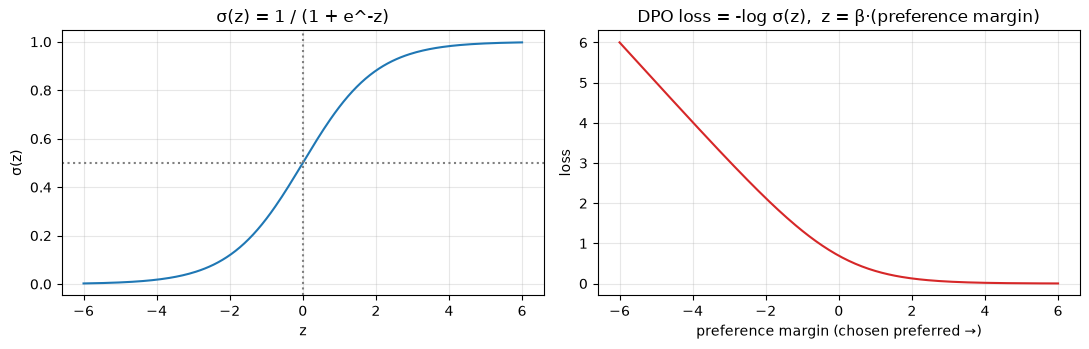

margin +4 -> loss 0.018
margin  0 -> loss 0.693  (model has no preference)
margin -4 -> loss 4.018  (confidently wrong)


In [11]:
# The sigmoid, and the DPO loss it produces, made concrete.
z = torch.linspace(-6, 6, 200)
sigmoid = torch.sigmoid(z)              # 1 / (1 + e^-z)
dpo_loss = -torch.log(sigmoid)          # -log σ(z): the loss as a function of β·margin

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))

ax1.plot(z, sigmoid, color='#1f77b4')
ax1.axhline(0.5, ls=':', c='gray'); ax1.axvline(0, ls=':', c='gray')
ax1.set_title('σ(z) = 1 / (1 + e^-z)'); ax1.set_xlabel('z'); ax1.set_ylabel('σ(z)')
ax1.grid(alpha=0.3)

ax2.plot(z, dpo_loss, color='#d62728')
ax2.set_title('DPO loss = -log σ(z),  z = β·(preference margin)')
ax2.set_xlabel('preference margin (chosen preferred →)'); ax2.set_ylabel('loss')
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Read the right panel: margin strongly positive (model prefers `chosen`) -> loss ~0;
# margin negative (model wrongly prefers `rejected`) -> large loss. Training pushes margins right.
print(f'margin +4 -> loss {(-torch.log(torch.sigmoid(torch.tensor(4.0)))).item():.3f}')
print(f'margin  0 -> loss {(-torch.log(torch.sigmoid(torch.tensor(0.0)))).item():.3f}  (model has no preference)')
print(f'margin -4 -> loss {(-torch.log(torch.sigmoid(torch.tensor(-4.0)))).item():.3f}  (confidently wrong)')

In [12]:
# Load a preference dataset: each example has a prompt, a "chosen" (good) response,
# and a "rejected" (bad) response
dpo_dataset = load_dataset('argilla/distilabel-intel-orca-dpo-pairs', split='train')

# Filter to only examples with clear quality differences
dpo_dataset = dpo_dataset.filter(lambda x: x['status'] != 'tie')

# Use a small subset for laptop training
dpo_dataset = dpo_dataset.select(range(200))

# Format as chat messages — DPOTrainer expects 'prompt', 'chosen', 'rejected' as message lists.
# Using the chat format avoids tokenization mismatches between prompt and prompt+response.
def format_dpo(example):
    return {
        'prompt': [{'role': 'user', 'content': example['input']}],
        'chosen': [{'role': 'assistant', 'content': example['chosen']}],
        'rejected': [{'role': 'assistant', 'content': example['rejected']}],
    }

dpo_dataset = dpo_dataset.map(format_dpo, remove_columns=dpo_dataset.column_names)

print(f'DPO training examples: {len(dpo_dataset)}')
print(f'\nExample:')
print(f"  Prompt:   {dpo_dataset[0]['prompt'][0]['content'][:100]}...")
print(f"  Chosen:   {dpo_dataset[0]['chosen'][0]['content'][:100]}...")
print(f"  Rejected: {dpo_dataset[0]['rejected'][0]['content'][:100]}...")

DPO training examples: 200

Example:
  Prompt:   Generate an approximately fifteen-word sentence that describes all this data: Midsummer House eatTyp...
  Chosen:   Midsummer House is a moderately priced Chinese restaurant with a 3/5 customer rating, located near A...
  Rejected:  Sure! Here's a sentence that describes all the data you provided:

"Midsummer House is a moderately...


In [13]:
# Free SFT model and base model from memory before loading DPO model
import gc
from peft import PeftModel

del model, base_model, trainer
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

# Load a fresh base model, then load the SFT adapter on top
# This way DPO continues from where SFT left off (base → SFT → DPO)
dpo_base = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float32,
)
dpo_base.config.pad_token_id = tokenizer.pad_token_id
dpo_base.generation_config.pad_token_id = tokenizer.pad_token_id
dpo_base.generation_config.max_length = None

# Load the SFT adapter we saved earlier — the LoRA A/B matrices trained on medical data
dpo_model = PeftModel.from_pretrained(dpo_base, './sft-adapter', is_trainable=True)
print(f'Loaded SFT adapter — DPO will refine these weights')
dpo_model.print_trainable_parameters()

# DPO uses more memory than SFT (2 forward passes per example) — keep everything minimal
dpo_config = DPOConfig(
    output_dir='./dpo-output',
    num_train_epochs=1,
    per_device_train_batch_size=1,   # DPO needs more memory (runs 2 forward passes per example)
    gradient_accumulation_steps=8,   # simulate batch_size=8
    learning_rate=5e-5,              # lower LR for DPO — it's a more delicate optimization
    max_length=256,                  # shorter sequences to fit in memory
    beta=0.1,                        # KL penalty — how much the model can diverge from reference
    logging_steps=5,                 # log frequently — DPO has fewer steps
    save_strategy='no',
    fp16=False, bf16=False,
    gradient_checkpointing=True,     # recompute activations to save memory
    dataloader_pin_memory=False,     # pin_memory not supported on MPS
    report_to='none',
    remove_unused_columns=False,
    disable_tqdm=False,              # show progress bar
)

dpo_trainer = DPOTrainer(
    model=dpo_model,
    ref_model=None,                  # with LoRA, use frozen base weights as reference — no second model copy
    args=dpo_config,
    train_dataset=dpo_dataset,
    processing_class=tokenizer,
)

print(f'Training {dpo_config.num_train_epochs} epoch(s), '
      f'{len(dpo_trainer.get_train_dataloader())} steps, '
      f'logging every {dpo_config.logging_steps} steps')
print('(DPO is slower — 2 forward passes per example)')
dpo_trainer.train()
print('Done!')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loaded SFT adapter — DPO will refine these weights
trainable params: 2,252,800 || all params: 1,102,301,184 || trainable%: 0.2044


Training 1 epoch(s), 200 steps, logging every 5 steps
(DPO is slower — 2 forward passes per example)


Step,Training Loss
5,0.667373
10,0.613873
15,0.577190
20,0.531242
25,0.503397


Done!


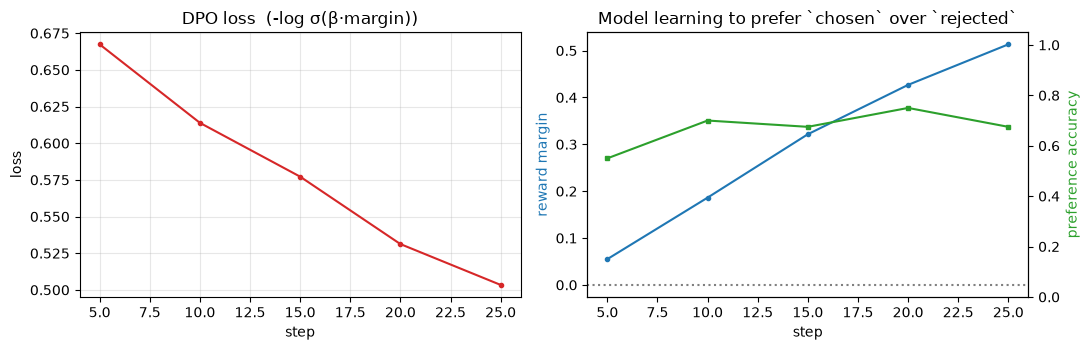

reward margin:       +0.055 -> +0.513  (higher = prefers chosen more)
preference accuracy: 0.55 -> 0.68  (fraction of pairs ranked correctly)


In [14]:
# DPO logs richer stats than SFT. Besides loss, it records:
#   rewards/margins    = mean of r(chosen) - r(rejected)  -> should climb above 0
#   rewards/accuracies = fraction of pairs where the model prefers chosen -> should climb toward 1
dpo_logs = [h for h in dpo_trainer.state.log_history if 'loss' in h and 'rewards/margins' in h]

if not dpo_logs:
    print('No reward stats logged; keys present:', sorted({k for h in dpo_trainer.state.log_history for k in h}))
else:
    steps   = [h['step'] for h in dpo_logs]
    loss    = [h['loss'] for h in dpo_logs]
    margins = [h['rewards/margins'] for h in dpo_logs]
    acc     = [h['rewards/accuracies'] for h in dpo_logs]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
    ax1.plot(steps, loss, marker='o', ms=3, color='#d62728')
    ax1.set_title('DPO loss  (-log σ(β·margin))'); ax1.set_xlabel('step'); ax1.set_ylabel('loss')
    ax1.grid(alpha=0.3)

    ax2.plot(steps, margins, marker='o', ms=3, color='#1f77b4', label='reward margin')
    ax2.axhline(0, ls=':', c='gray')
    ax2.set_xlabel('step'); ax2.set_ylabel('reward margin', color='#1f77b4')
    axb = ax2.twinx()
    axb.plot(steps, acc, marker='s', ms=3, color='#2ca02c', label='pref. accuracy')
    axb.set_ylabel('preference accuracy', color='#2ca02c'); axb.set_ylim(0, 1.05)
    ax2.set_title('Model learning to prefer `chosen` over `rejected`')
    plt.tight_layout(); plt.show()

    print(f'reward margin:       {margins[0]:+.3f} -> {margins[-1]:+.3f}  (higher = prefers chosen more)')
    print(f'preference accuracy: {acc[0]:.2f} -> {acc[-1]:.2f}  (fraction of pairs ranked correctly)')

### Generate after DPO

The DPO-trained model has learned to prefer higher-quality responses. We compare all three stages: base model (no adapter), after SFT (loaded from saved adapter), and after DPO. PEFT lets us load multiple adapters on the same base model and switch between them.

In [15]:
# Load the SFT adapter as a second adapter named "sft" — no extra base model copy needed
dpo_model.load_adapter('./sft-adapter', adapter_name='sft')

rows = ['| Question | Base Model | After SFT | After DPO |\n|----------|------------|-----------|-----------|']
for p in medical_prompts:
    # Base model: disable all adapters
    dpo_model.disable_adapter_layers()
    base_answer = generate(dpo_model, p).replace('\n', ' ').replace('|', '\\|')
    dpo_model.enable_adapter_layers()

    # SFT model: switch to the saved SFT adapter
    dpo_model.set_adapter('sft')
    sft_answer = generate(dpo_model, p).replace('\n', ' ').replace('|', '\\|')

    # DPO model: switch back to the default (DPO-trained) adapter
    dpo_model.set_adapter('default')
    dpo_answer = generate(dpo_model, p).replace('\n', ' ').replace('|', '\\|')

    rows.append(f'| {p} | {base_answer[:200]} | {sft_answer[:200]} | {dpo_answer[:200]} |')

display(Markdown('\n'.join(rows)))

| Question | Base Model | After SFT | After DPO |
|----------|------------|-----------|-----------|
| What are the common symptoms of pneumonia? | The following are some common symptoms of pneumonia:  1. Fever (at least 38°C or higher) 2. Cough (persistent and productive, with sputum production) 3. Chest pain (dull or sharp) 4. Shortness of brea | Pneumonia is a condition characterized by inflammation and infection of the lungs. The most commonly reported symptom is cough, which may be productive or non-productive. Other signs that could indica | Pneumonia is a disease that can cause severe pain and discomfort in your chest, making it difficult to breathe. The most commonly observed symptom of pneumonia is fever (high temperature), coughing up |
| What is the difference between type 1 and type 2 diabetes? | Type 1 diabetes (T1D) and type 2 diabetes are two types of diabetes that differ in their underlying causes, symptoms, and treatment options. Here's a brief comparison:  1. Cause: T1D occurs when the p | Type 1 diabetes (T1D) is a chronic autoimmune disease that results from the destruction of insulin-producing cells in the pancreas. This condition typically presents as early childhood or adolescence, | Type 1 diabetes is a form of diabetes that causes the body to produce little or no insulin, while type 2 diabetes involves an inability to use insulin properly. Type 1 diabetes typically affects young |
| What is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels? | Very low Mg2+ levels (below 50 nM) can lead to a decrease in PTH levels. This occurs because PTH is produced by the parathyroid gland when there are too many calcium ions in the bloodstream. Increased | Very low Mg2+ levels can cause an increase in PTH levels due to increased intracellular calcium levels. This leads to a decrease in the concentration of calcium ions in the extracellular space, which  | Very low Mg2+ levels are associated with high PTH levels and a reduced level of Ca2+ in patients. This can cause calcium to accumulate in various organs, leading to the symptoms seen when these condit |

## Summary

| Step | Technique | What the model learns | How it's scored | Training data |
|------|-----------|----------------------|-----------------|---------------|
| 0 | Base model | Already pretrained on internet text | — | — |
| 1 | LoRA setup | Nothing yet — adds trainable low-rank adapters | — | — |
| 2 | SFT | Imitate good instruction→response pairs | cross-entropy `-log p(next token)` | (instruction, response) |
| 3 | DPO | Prefer good responses over bad ones | `-log σ(β·preference-margin)` | (prompt, chosen, rejected) |

**The through-line, end to end.** We started with a pretrained next-token predictor (TinyLlama) that continued text but answered vaguely. **LoRA** let us train it on a laptop by touching only ~0.2% of its weights (the red sliver plot). **SFT** taught it to answer medical questions — the same cross-entropy training as the transformer notebook, its loss falling as the adapter learned. **DPO** then taught it to answer *well*, turning pairwise preferences into a logistic-regression loss whose reward-margin and accuracy curves climbed as the model learned to rank good answers above bad. That's the full **pretrain → SFT → DPO** pipeline behind modern chat assistants, run start to finish on a laptop.

Two ideas did the heavy lifting and are worth carrying forward: a model's preference for a response is its **log-probability** (a sum of per-token log-probs), and the **sigmoid** turns any score gap into a probability — the hinge that makes DPO a simple classification problem.

### What we learned

- **Fine-tuning doesn't change the machinery** — same next-token model, same cross-entropy loss as the transformer notebook. What changes is the *data* (SFT) and then the *loss* (DPO).
- **LoRA's bet is that the weight *change* is low-rank**: freeze `W`, train two skinny matrices whose product `BA` is the update. ~0.2% of parameters trained, full model behavior changed, base weights untouched and swappable.
- **SFT is imitation**: show (instruction → good response) pairs and minimize `-log p(response)`. It teaches format and domain, not judgment.
- **A model's preference for a response is its log-probability** — the sum of per-token log-probs. That single idea is what lets DPO compare two answers with no reward model.
- **DPO turns preferences into classification**: `-log σ(β · margin)` pushes the chosen answer's log-prob up relative to the rejected one, with the frozen reference model as the anchor. No reinforcement learning required.
- **The modern assistant recipe is a pipeline**: pretrain (predict the internet) → SFT (act like an assistant) → preference optimization (act like a *good* one). Each stage reuses the previous stage's weights.

## Next steps

1. **Merge the adapter** — `model.merge_and_unload()` bakes the LoRA weights into the base model for faster inference (no adapter overhead).
2. **Try different datasets** — fine-tune on code, legal text, or any domain by swapping the dataset.
3. **Quantization (QLoRA)** — 4-bit quantize the frozen base to fit much larger models on the same hardware.
4. **Evaluate properly** — the side-by-side tables here are eyeballing; real work uses held-out benchmarks or human ratings.

## Your turn: make it stick

Reading along is the comfortable half of learning — and this is the last notebook, so this is the exam.

### 1. Summarize it yourself, then verify with an LLM

Close the notebook and write a summary from memory — a few sentences per question, no peeking:

- What is LoRA's core bet, and what do the two matrices `B` and `A` do? Why does this make laptop training possible?
- What does SFT optimize, and what can't it teach?
- How do you get a single number for "how much does the model prefer this response"?
- Write the DPO loss in words. What role does the frozen reference model play, and what does β control?
- Why is the pipeline ordered pretrain → SFT → DPO, and what does each stage inherit from the previous one?

Then paste your summary into an LLM with a prompt like:

> *"I just studied parameter-efficient fine-tuning: LoRA, SFT, and DPO. Here is my summary from memory: [your summary]. Check every claim for correctness, tell me what I've missed or muddled, then quiz me with three follow-up questions aimed at my weakest spot."*

### 2. Rebuild a small version

Two rebuilds, one tiny and one end-to-end:

1. **The DPO loss in raw Python** (15 minutes, no GPU). Write `dpo_loss(chosen_logp, rejected_logp, ref_chosen_logp, ref_rejected_logp, beta)` using nothing but `math.exp`. Feed it hand-picked numbers and check it behaves: loss near `-log(0.5) ≈ 0.69` when the margin is zero, falling toward 0 as the policy prefers the chosen answer more than the reference does, growing when it prefers the rejected one. Then raise β and watch the same margins get punished harder.
2. **Your own SFT run.** Write ~20 instruction→response pairs in a domain you know (your codebase's conventions, your hobby, your city). Swap them into this notebook's SFT step and retrain the LoRA adapter. Generate from the same prompts before and after.

**Done when**: your toy loss function's behavior matches the three checks, and the fine-tuned model visibly answers in your domain's style where the base model rambled. Bonus: write 5 preference pairs and run the DPO step on them too — the full pipeline, on data that is entirely yours.
